In [167]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling2D, LSTM
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dropout
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from tensorflow.keras.callbacks import EarlyStopping
import os
import math
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import seaborn as sns
%matplotlib inline
#맥에서 한글 안깨지게


rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정

In [168]:
!which python

/opt/homebrew/Caskroom/miniconda/base/envs/apt_sale/bin/python


# 1. 경로 및 파라미터 설정

In [177]:
# ❗️ 1-1. 사용자 설정 경로 및 변수
TABULAR_DATA_PATH = '../data/interim/gang_nam_sendimental_score_with_sale.csv'
IMAGE_DIRECTORY = '../data/interim/satellites/rot_90'
IMAGE_EXTENSION = '.jpg' # 이미지 파일 확장자 (.png, .jpeg 등)
DATE_COLUMN = '계약일자'
TARGET_COLUMN = '면적당 단가(만원)' # 예측할 실제 타겟 컬럼명

# 1-2. 모델 파라미터
LOOKBACK = 10      # 과거 10개의 거래 데이터를 보고 다음 거래를 예측
BATCH_SIZE = 64
EPOCHS = 100

# 2. 데이터 로드 및 전처리

In [178]:
# 2-1. CSV 파일 로드 및 날짜 기준 정렬
#print("1. 데이터를 로드하고 정렬합니다...")
df = pd.read_csv(TABULAR_DATA_PATH)
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df = df.sort_values(DATE_COLUMN).reset_index(drop=True)

In [179]:
df.head()

,전용면적(㎡),거래금액(만원),층,건축년도,면적당 단가(만원),아파트 나이,구,계약일자,계약년월,alpha,sentiment_score
0,84.96,115000,6,2011,7.210507,9,강남구,2020-07-11,202007,1.000000,0.014421
1,59.40,134000,4,1997,7.721301,23,강남구,2020-07-11,202007,0.233333,0.014421
2,84.83,139000,6,2013,7.401580,7,강남구,2020-07-11,202007,1.000000,0.014421
3,96.98,210000,12,1984,7.680358,36,강남구,2020-07-11,202007,0.000000,0.014421
4,111.96,91000,2,2004,6.700473,16,강남구,2020-07-11,202007,0.466667,0.014421


In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   전용면적(㎡)          8907 non-null   float64       
 1   층                8907 non-null   int64         
 2   건축년도             8907 non-null   int64         
 3   면적당 단가(만원)       8907 non-null   float64       
 4   아파트 나이           8907 non-null   int64         
 5   계약일자             8907 non-null   datetime64[ns]
 6   alpha            8907 non-null   float64       
 7   sentiment_score  8907 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 556.8 KB


In [183]:
# 2-2. 이미지 전체 경로 생성
df['image_filename'] = [f'apt_image_{i}{IMAGE_EXTENSION}' for i in df.index]
df['image_path'] = df['image_filename'].apply(lambda filename: os.path.join(IMAGE_DIRECTORY, filename))

# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename'])
y_target = df[TARGET_COLUMN]

# 2-4. 숫자형 특징 스케일링
#print("2. 데이터를 전처리합니다...")
numeric_features = X_tabular.select_dtypes(include=np.number).columns.tolist()
#scaler = StandardScaler()
scaler = RobustScaler()
X_tabular[numeric_features] = scaler.fit_transform(X_tabular[numeric_features])
print("=========================")
print("최종 전처리 완료된 데이터 입니다.")
print("=========================\n")
df.info()

최종 전처리 완료된 데이터 입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   전용면적(㎡)          8907 non-null   float64       
 1   층                8907 non-null   int64         
 2   건축년도             8907 non-null   int64         
 3   면적당 단가(만원)       8907 non-null   float64       
 4   아파트 나이           8907 non-null   int64         
 5   계약일자             8907 non-null   datetime64[ns]
 6   alpha            8907 non-null   float64       
 7   sentiment_score  8907 non-null   float64       
 8   image_filename   8907 non-null   object        
 9   image_path       8907 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 696.0+ KB


In [184]:
df.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,alpha,sentiment_score,image_filename,image_path
0,84.96,6,2011,7.210507,9,2020-07-11,1.0,0.014421,apt_image_0.jpg,../data/interim/satellites/rot_90/apt_image_0.jpg


In [185]:
df.describe()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,alpha,sentiment_score
count,8907.000000,8907.000000,8907.000000,8907.000000,8907.000000,8907,8907.000000,8907.000000
mean,92.420245,9.865162,2000.241046,7.767764,22.476928,2023-03-11 04:54:33.829572352,0.490806,0.024593
min,12.100000,-1.000000,1974.000000,5.689222,0.000000,2020-07-11 00:00:00,0.000000,-0.023728
25%,59.960000,4.000000,1992.000000,7.540496,13.000000,2021-07-09 12:00:00,0.000000,0.017387
50%,84.840000,8.000000,2003.000000,7.835593,20.000000,2023-07-21 00:00:00,0.500000,0.023976
75%,114.970000,13.000000,2009.000000,8.064332,32.000000,2024-08-02 12:00:00,1.000000,0.032320
max,301.470000,68.000000,2024.000000,9.083827,50.000000,2025-06-16 00:00:00,1.000000,0.056953
std,44.359039,8.084657,12.468777,0.406649,12.498507,NaN,0.414343,0.012387


# 3. 다중 모달 특징 추출

In [186]:
# --- 3. 다중 모달 특징 추출 ---

# 3-1. 특징 추출기 모델 정의 (수정 없음, Input 레이어의 name이 중요해짐)
print("3. 특징 추출기 모델을 정의합니다...")
def create_feature_extractor_model(num_tabular_features, image_shape=(224, 224, 3)):
    # ❗️ 아래 name들이 딕셔너리의 key와 일치해야 함
    tabular_input = Input(shape=(num_tabular_features,), name='tabular_input')
    image_input = Input(shape=image_shape, name='image_input')
    
    x1 = Dense(64, activation='relu')(tabular_input)
    tabular_features = Dense(32, activation='relu')(x1)

    base_cnn = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    base_cnn.trainable = False
    x2 = GlobalAveragePooling2D()(base_cnn.output)
    x2 = Dense(128, activation='relu')(x2)
    image_features = Dense(64, activation='relu')(x2)

    combined_features = Concatenate()([tabular_features, image_features])
    
    model = Model(inputs=[tabular_input, image_input], outputs=combined_features, name='feature_extractor')
    return model

# 3-2. 특징 추출을 위한 데이터 제너레이터 (수정됨)
def prediction_generator(tabular_data, image_paths, batch_size, image_shape=(224, 224, 3)):
    num_samples = len(tabular_data)
    for offset in range(0, num_samples, batch_size):
        batch_tabular = tabular_data.iloc[offset:offset+batch_size].values
        batch_paths = image_paths.iloc[offset:offset+batch_size]
        
        batch_images = []
        for path in batch_paths:
            try:
                img = load_img(path, target_size=image_shape[:2])
                img_array = img_to_array(img) / 255.0
                batch_images.append(img_array)
            except FileNotFoundError:
                batch_images.append(np.zeros(image_shape))
        
        # ❗️ [수정] 모델의 Input 레이어 이름에 맞춰 딕셔너리 형태로 반환
        yield {
            'tabular_input': np.array(batch_tabular),
            'image_input': np.array(batch_images)
        }

# 3-3. 전체 데이터에 대한 특징 추출 실행 (수정됨)
print("4. 전체 데이터에 대한 특징을 추출합니다...")
feature_extractor = create_feature_extractor_model(num_tabular_features=X_tabular.shape[1])

# ❗️ [수정] 출력 형식을 딕셔너리 구조로 명시
output_signature = {
    'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
    'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
}

# from_generator를 사용하여 데이터셋 생성
pred_dataset = tf.data.Dataset.from_generator(
    lambda: prediction_generator(X_tabular, df['image_path'], BATCH_SIZE),
    output_signature=output_signature
)

# predict 함수에 tf.data.Dataset을 직접 전달
all_features = feature_extractor.predict(pred_dataset, verbose=1)

print("\n🎉 특징 추출이 성공적으로 완료되었습니다!")
print("추출된 특징의 모양:", all_features.shape)

3. 특징 추출기 모델을 정의합니다...
4. 전체 데이터에 대한 특징을 추출합니다...


2025-09-10 13:35:15.347670: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


140/140 [==============================] - 219s 2s/step

🎉 특징 추출이 성공적으로 완료되었습니다!
추출된 특징의 모양: (8907, 96)


# 4. 시퀸스 데이터 생성

In [188]:
# --- 4. 시퀀스 데이터 생성 ---

print("\n5. 시계열 데이터를 생성합니다...")
def create_sequences(X_data, y_data, lookback):
    X_sequences, y_sequences = [], []
    # 데이터 길이에서 lookback 길이를 뺀 만큼 반복
    for i in range(len(X_data) - lookback):
        # i부터 i+lookback까지의 데이터를 하나의 시퀀스로
        X_sequences.append(X_data[i:(i + lookback)])
        # 시퀀스 바로 다음의 데이터를 정답으로
        y_sequences.append(y_data[i + lookback])
    return np.array(X_sequences), np.array(y_sequences)

# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(all_features, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]



5. 시계열 데이터를 생성합니다...
생성된 시퀀스 데이터 모양 (X): (8897, 10, 96)
생성된 시퀀스 데이터 모양 (y): (8897,)


# 미래 시점 예측하기

In [197]:
def create_lstm_model(input_shape):
    input_layer = Input(shape=input_shape)
    x = LSTM(128, activation='tanh', return_sequences=True)(input_layer)
    x = Dropout(0.2)(x) # 드롭아웃 추가
    lstm_out = LSTM(64, activation='tanh', return_sequences=False)(x)
    x = Dropout(0.2)(lstm_out) # 드롭아웃 추가
    prediction = Dense(1, activation='linear')(x)

    model = Model(inputs=input_layer, outputs=prediction, name='lstm_forecaster')
    return model

In [198]:
def create_future_sequences(all_features, original_df, lookback=10, horizon_days=30):
    """
    특정 기간(horizon_days) 후의 가격을 예측하기 위한 시계열 데이터를 생성합니다.
    
    :param all_features: (샘플 수, 특징 수) 모양의 전체 특징 데이터
    :param original_df: 날짜와 타겟 컬럼이 포함된 원본 데이터프레임
    :param lookback: 과거를 돌아볼 기간 (시퀀스 길이)
    :param horizon_days: 예측할 미래 기간 (일 단위)
    :return: X_sequences (입력 시퀀스), y_sequences (미래 시점의 정답)
    """
    X_sequences, y_sequences = [], []
    
    # 날짜와 타겟 값을 쉽게 조회할 수 있도록 Series로 변환
    dates = original_df['계약일자']
    targets = original_df[TARGET_COLUMN].values
    
    for i in range(len(all_features) - lookback):
        # 입력 시퀀스의 마지막 날짜
        end_of_input_sequence_date = dates[i + lookback - 1]
        
        # 예측 목표 날짜 설정
        target_date = end_of_input_sequence_date + pd.Timedelta(days=horizon_days)
        
        # 목표 날짜 이후의 데이터만 필터링
        future_data_indices = np.where(dates >= target_date)[0]
        
        # 목표 날짜 이후에 거래가 있다면
        if len(future_data_indices) > 0:
            # 가장 가까운 미래 거래의 인덱스를 찾음
            future_target_index = future_data_indices[0]
            
            # 해당 인덱스가 전체 특징 데이터 길이를 벗어나지 않는지 확인
            if future_target_index < len(all_features):
                # 입력 시퀀스 생성
                X_sequences.append(all_features[i:(i + lookback)])
                # 미래 시점의 가격을 정답으로 지정
                y_sequences.append(targets[future_target_index])
                
    return np.array(X_sequences), np.array(y_sequences)

In [199]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 8759
3개월 후 예측용 데이터 샘플 수: 8601
6개월 후 예측용 데이터 샘플 수: 7577


In [200]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]

In [201]:
# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

2025-09-10 13:54:38.204229: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:54:38.205197: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:54:38.205575: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100


2025-09-10 13:54:38.502339: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:54:38.503074: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:54:38.503478: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

105/110 [===========================>..] - ETA: 0s - loss: 55.0079 - mae: 7.4044

2025-09-10 13:54:40.637887: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:54:40.638412: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:54:40.638802: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

...

106/108 [============================>.] - ETA: 0s - loss: 56.4654 - mae: 7.5012

2025-09-10 13:55:15.812393: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:55:15.812984: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:55:15.813328: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

108/108 [==============================] - 2s 12ms/step - loss: 56.4029 - mae: 7.4970 - val_loss: 56.3995 - val_mae: 7.4971
Epoch 2/100
108/108 [==============================] - 1s 10ms/step - loss: 47.9853 - mae: 6.9111 - val_loss: 46.5751 - val_mae: 6.8105
Epoch 3/100
108/108 [==============================] - 1s 9ms/step - loss: 37.4260 - mae: 6.0953 - val_loss: 34.4013 - val_mae: 5.8489
Epoch 4/100
108/108 [==============================] - 1s 9ms/step - loss: 25.5584 - mae: 5.0211 - val_loss: 21.9005 - val_mae: 4.6593
Epoch 5/100
108/108 [==============================] - 1s 10ms/step - loss: 14.9956 - mae: 3.8194 - val_loss: 12.3186 - val_mae: 3.4824
Epoch 6/100
108/108 [==============================] - 1s 10ms/step - loss: 8.1174 - mae: 2.7724 - val_loss: 6.5395 - val_mae: 2.5195
Epoch 7/100
108/108 [==============================] - 1s 9ms/step - loss: 4.2077 - mae: 1.9403 - val_loss: 3.4933 - val_mae: 1.8170
Epoch 8/100
108/108 [==============================] - 1s 10ms/step

2025-09-10 13:55:49.520209: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:55:49.520819: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:55:49.521209: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
110/110 [==============================] - 1s 10ms/step - loss: 0.4644 - mae: 0.5422 - val_loss: 0.2189 - val_mae: 0.3981
Epoch 2/100
110/110 [==============================] - 1s 10ms/step - loss: 0.4626 - mae: 0.5399 - val_loss: 0.2209 - val_mae: 0.4000
Epoch 3/100
110/110 [==============================] - 1s 10ms/step - loss: 0.4776 - mae: 0.5520 - val_loss: 0.2196 - val_mae: 0.3988
Epoch 4/100
110/110 [==============================] - 1s 9ms/step - loss: 0.4675 - mae: 0.5432 - val_loss: 0.2164 - val_mae: 0.3957
Epoch 5/100
110/110 [==============================] - 1s 12ms/step - loss: 0.4644 - mae: 0.5433 - val_loss: 0.2137 - val_mae: 0.3931
Epoch 6/100
110/110 [==============================] - 1s 10ms/step - loss: 0.4463 - mae: 0.5328 - val_loss: 0.2189 - val_mae: 0.3980
Epoch 7/100
110/110 [==============================] - 1s 11ms/step - loss: 0.4728 - mae: 0.5492 - val_loss: 0.2179 - val_mae: 0.3971
Epoch 8/100
110/110 [===============


--- 1개월 후 예측 모델 성능 분석 시작 ---
 1/55 [..............................] - ETA: 12s

2025-09-10 13:56:01.722651: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:56:01.723570: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:56:01.723988: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

55/55 [==============================] - 0s 2ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 2484.94 (만원)  |  예측 단가: 2365.57 (만원)
실제 단가: 2484.94 (만원)  |  예측 단가: 2390.40 (만원)
실제 단가: 2484.94 (만원)  |  예측 단가: 2419.48 (만원)
실제 단가: 2484.94 (만원)  |  예측 단가: 2397.86 (만원)
실제 단가: 2484.94 (만원)  |  예측 단가: 2406.82 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
모델 평가 결과 (Log Scaled MAE): 0.3931
역변환 후 실제 오차 (Real World MAE): 1102.87 (만원)


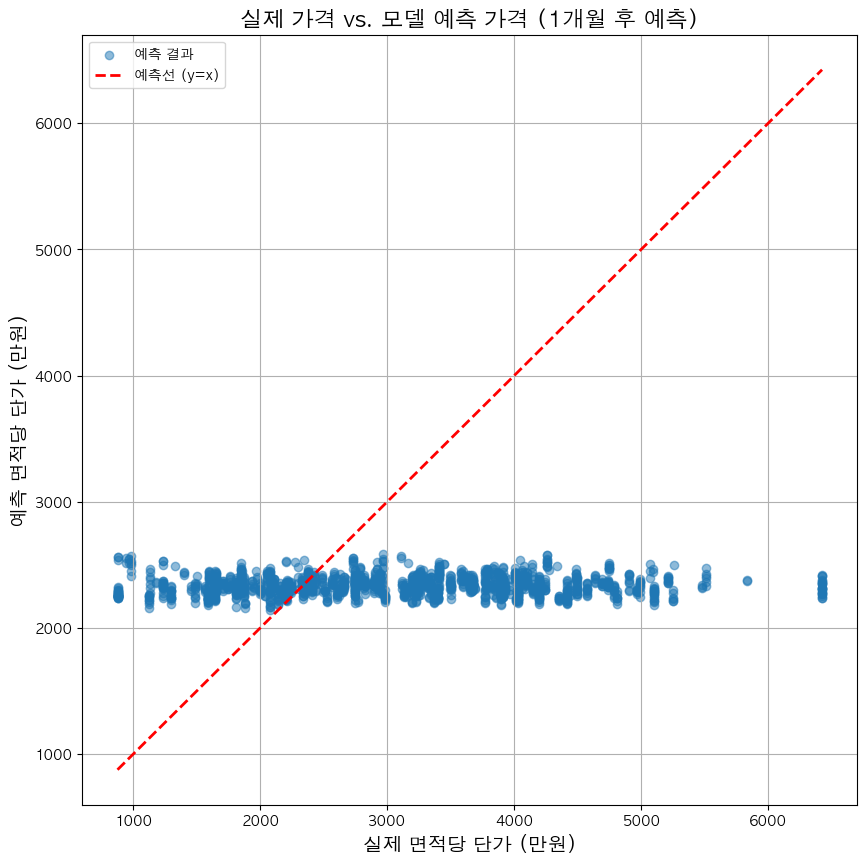


--- 3개월 후 예측 모델 성능 분석 시작 ---
30/54 [===============>..............] - ETA: 0s 

2025-09-10 13:56:02.277895: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:56:02.278792: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:56:02.279176: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

54/54 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 4966.09 (만원)  |  예측 단가: 2255.52 (만원)
실제 단가: 4966.09 (만원)  |  예측 단가: 2254.99 (만원)
실제 단가: 4966.09 (만원)  |  예측 단가: 2255.19 (만원)
실제 단가: 4966.09 (만원)  |  예측 단가: 2245.45 (만원)
실제 단가: 4966.09 (만원)  |  예측 단가: 2250.77 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
모델 평가 결과 (Log Scaled MAE): 0.4339
역변환 후 실제 오차 (Real World MAE): 1232.04 (만원)


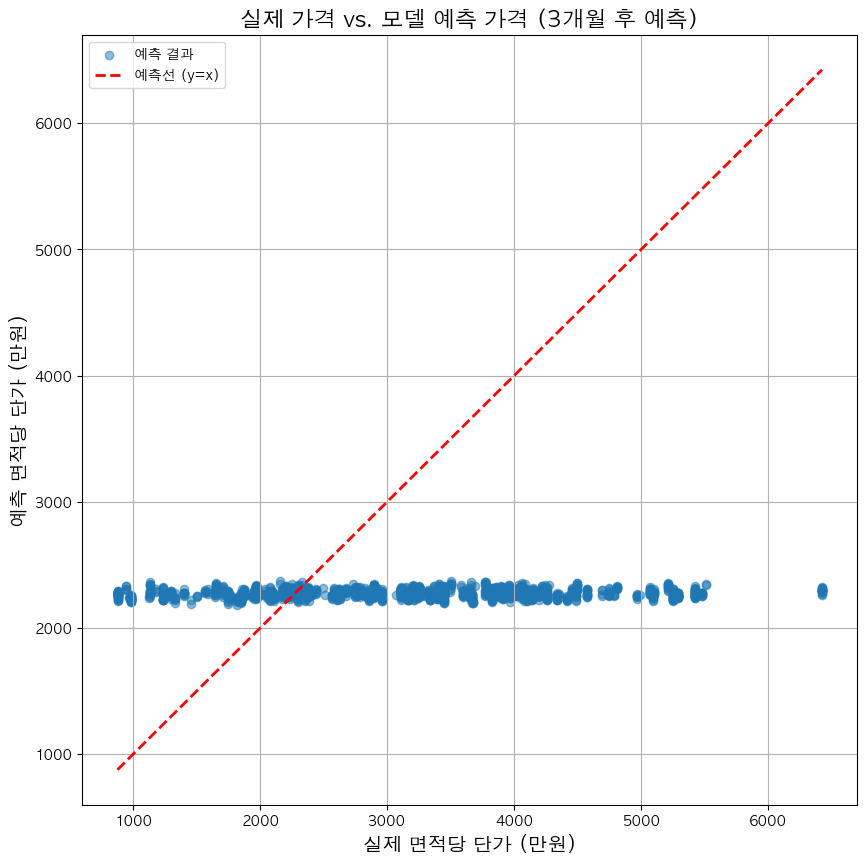


--- 6개월 후 예측 모델 성능 분석 시작 ---
32/48 [===================>..........] - ETA: 0s 

2025-09-10 13:56:02.776572: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:56:02.777077: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:56:02.777475: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

48/48 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 3771.04 (만원)  |  예측 단가: 0.98 (만원)
실제 단가: 3771.04 (만원)  |  예측 단가: 0.98 (만원)
실제 단가: 3771.04 (만원)  |  예측 단가: 0.98 (만원)
실제 단가: 3771.04 (만원)  |  예측 단가: 0.98 (만원)
실제 단가: 3771.04 (만원)  |  예측 단가: 0.98 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---


2025-09-10 13:56:03.118942: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-09-10 13:56:03.119530: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-09-10 13:56:03.119893: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

모델 평가 결과 (Log Scaled MAE): 8.0339
역변환 후 실제 오차 (Real World MAE): 3192.42 (만원)


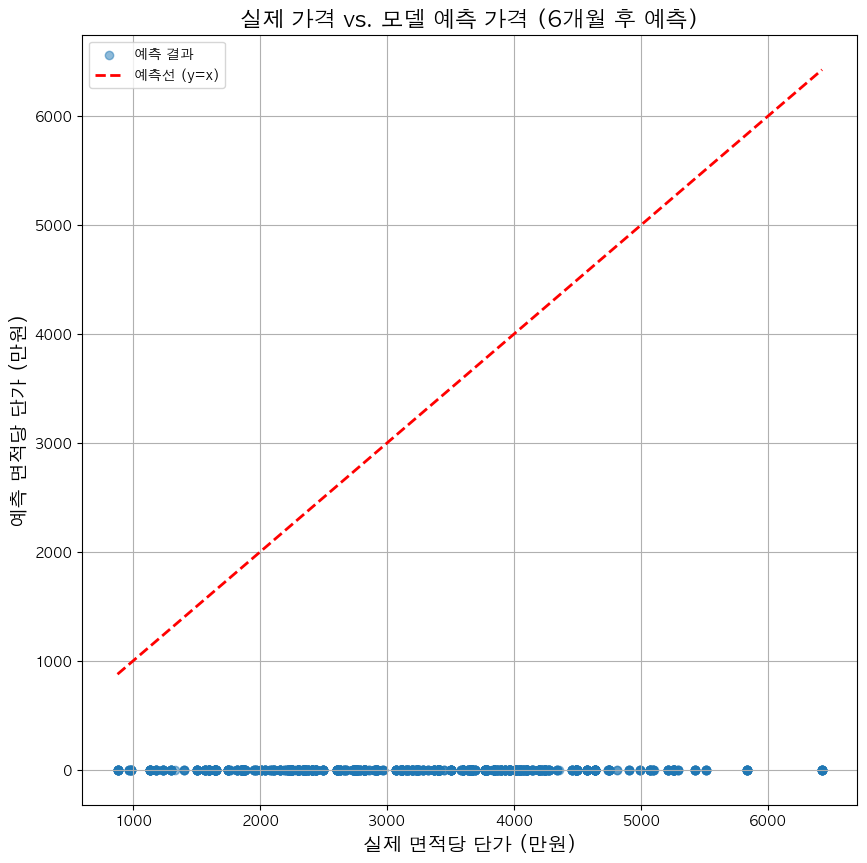

In [202]:

# --- 분석 및 시각화 함수 정의 ---
def analyze_and_visualize_model(model, X_test_seq, y_test_seq, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    
    :param model: 학습이 완료된 Keras 모델
    :param X_test_seq: 테스트용 입력 시퀀스 데이터
    :param y_test_seq: 테스트용 정답 시퀀스 데이터 (로그 스케일)
    :param model_name: 그래프 제목 등에 사용할 모델 이름 (예: "1개월 후 예측")
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 테스트셋으로 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_seq)

    # 2. 실제 값과 예측 값 역변환 (로그 -> 원본 단위)
    # np.exp()를 사용하여 로그 변환된 값을 원래 스케일로 되돌립니다.
    y_test_original = np.exp(y_test_seq)
    y_pred_original = np.exp(y_pred_log)

    # 3. 원본 단위(만원)로 MAE 계산
    real_world_mae = mean_absolute_error(y_test_original, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(5):
        print(f"실제 단가: {y_test_original.flatten()[i]:.2f} (만원)  |  예측 단가: {y_pred_original.flatten()[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    # model.evaluate() 결과는 로그 스케일의 MAE
    _, scaled_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
    print(f"모델 평가 결과 (Log Scaled MAE): {scaled_mae:.4f}")
    print(f"역변환 후 실제 오차 (Real World MAE): {real_world_mae:.2f} (만원)")

    # 5. 성능 시각화 (원본 단위)
    plt.rc('axes', unicode_minus=False)

    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_original, y_pred_original, alpha=0.5, label='예측 결과')
    plt.plot([min(y_test_original.flatten()), max(y_test_original.flatten())], 
             [min(y_test_original.flatten()), max(y_test_original.flatten())], 
             '--r', linewidth=2, label='예측선 (y=x)')
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


# --- 함수 실행 ---
# 이전에 학습시킨 1개월, 6개월 모델과 테스트 데이터셋을 사용합니다.
# (lstm_model_1m, X_test_1m, y_test_1m 등이 메모리에 있다고 가정)
# (lstm_model_6m, X_test_6m, y_test_6m 등도 학습 완료되었다고 가정)

# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")


In [203]:
# 시계열이 아닌 개별 데이터를 사용하므로, 시퀀스 생성을 하지 않습니다.
# all_features와 y_target을 짝에 맞게 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(
    all_features, 
    y_target, 
    test_size=0.2, 
    random_state=42 # 시계열이 아니므로 랜덤 분리 가능
)

def create_mlp_model(input_shape):
    input_layer = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    prediction = Dense(1, activation='linear')(x)
    model = Model(inputs=input_layer, outputs=prediction)
    return model

# MLP 모델 생성 및 학습
mlp_model = create_mlp_model(X_train.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
mlp_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
mlp_model.summary()

history = mlp_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

# 이 모델의 예측 결과를 시각화하여 수평선이 나오는지 확인합니다.

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_40 (InputLayer)       [(None, 96)]              0         
                                                                 
 dense_87 (Dense)            (None, 128)               12416     
                                                                 
 dense_88 (Dense)            (None, 64)                8256      
                                                                 
 dense_89 (Dense)            (None, 1)                 65        
                                                                 
Total params: 20,737
Trainable params: 20,737
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
223/223 [==============================] - 0s 608us/step - loss: 28.5414 - mae: 4.9497 - val_loss: 1.6694 - val_mae: 1.1772
Epoch 2/100
223/223 [==============================


--- MLP 기본 모델 모델 성능 분석 시작 ---
56/56 [==============================] - 0s 193us/step
--- MLP 기본 모델: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 4186.28 (만원)  |  예측 단가: 4073.47 (만원)
실제 단가: 1001.52 (만원)  |  예측 단가: 890.28 (만원)
실제 단가: 3242.61 (만원)  |  예측 단가: 3363.71 (만원)
실제 단가: 1224.11 (만원)  |  예측 단가: 2055.46 (만원)
실제 단가: 2049.69 (만원)  |  예측 단가: 2569.39 (만원)

--- MLP 기본 모델: 최종 실제 오차 (원본 단위) ---
모델 평가 결과 (Log Scaled MAE): 0.2433
역변환 후 실제 오차 (Real World MAE): 572.18 (만원)


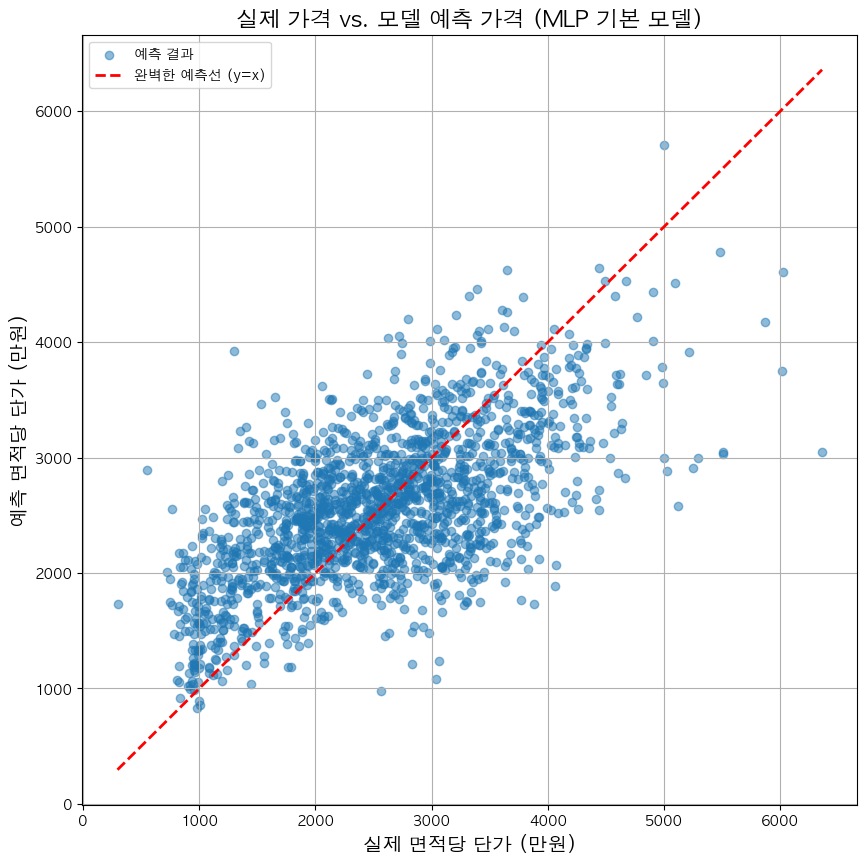

In [204]:
# --- 분석 및 시각화 함수 (수정된 버전) ---
def analyze_and_visualize_model(model, X_test_data, y_test_data, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행
    y_pred_log = model.predict(X_test_data)

    # 2. 역변환
    y_test_original = np.exp(y_test_data)
    y_pred_original = np.exp(y_pred_log)
    
    # ❗️ [수정] Series일 경우를 대비하여 .values를 사용, NumPy 배열로 통일
    y_test_np = y_test_original.values if isinstance(y_test_original, pd.Series) else y_test_original
    # model.predict의 결과는 이미 NumPy 배열이므로 y_pred_original은 그대로 사용
    
    # 3. MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(5):
        # ❗️ [수정] .flatten()을 안전하게 사용하기 위해 NumPy 배열인 y_test_np를 사용
        print(f"실제 단가: {y_test_np.flatten()[i]:.2f} (만원)  |  예측 단가: {y_pred_original.flatten()[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    _, scaled_mae = model.evaluate(X_test_data, y_test_data, verbose=0)
    print(f"모델 평가 결과 (Log Scaled MAE): {scaled_mae:.4f}")
    print(f"역변환 후 실제 오차 (Real World MAE): {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    # ❗️ [수정] 시각화 시에도 NumPy 배열인 y_test_np를 사용
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    plt.plot([min(y_test_np.flatten()), max(y_test_np.flatten())], 
             [min(y_test_np.flatten()), max(y_test_np.flatten())], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 함수 재호출 ---
# 이제 MLP 모델에 대한 분석을 다시 실행합니다.
analyze_and_visualize_model(mlp_model, X_test, y_test, "MLP 기본 모델")

# XGBoost

In [206]:
df.head()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,alpha,sentiment_score,image_filename,image_path
0,84.96,6,2011,7.210507,9,2020-07-11,1.000000,0.014421,apt_image_0.jpg,../data/interim/satellites/rot_90/apt_image_0.jpg
1,59.40,4,1997,7.721301,23,2020-07-11,0.233333,0.014421,apt_image_1.jpg,../data/interim/satellites/rot_90/apt_image_1.jpg
2,84.83,6,2013,7.401580,7,2020-07-11,1.000000,0.014421,apt_image_2.jpg,../data/interim/satellites/rot_90/apt_image_2.jpg
3,96.98,12,1984,7.680358,36,2020-07-11,0.000000,0.014421,apt_image_3.jpg,../data/interim/satellites/rot_90/apt_image_3.jpg
4,111.96,2,2004,6.700473,16,2020-07-11,0.466667,0.014421,apt_image_4.jpg,../data/interim/satellites/rot_90/apt_image_4.jpg



--- XGBoost 미래 예측 모델 성능 분석 시작 ---
--- XGBoost 미래 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 7.83 (만원)  |  예측 단가: 7.81 (만원)
실제 단가: 7.66 (만원)  |  예측 단가: 7.68 (만원)
실제 단가: 7.64 (만원)  |  예측 단가: 7.59 (만원)
실제 단가: 7.94 (만원)  |  예측 단가: 7.89 (만원)
실제 단가: 7.74 (만원)  |  예측 단가: 7.87 (만원)

--- XGBoost 미래 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE (30일 후): 0.10 (만원)


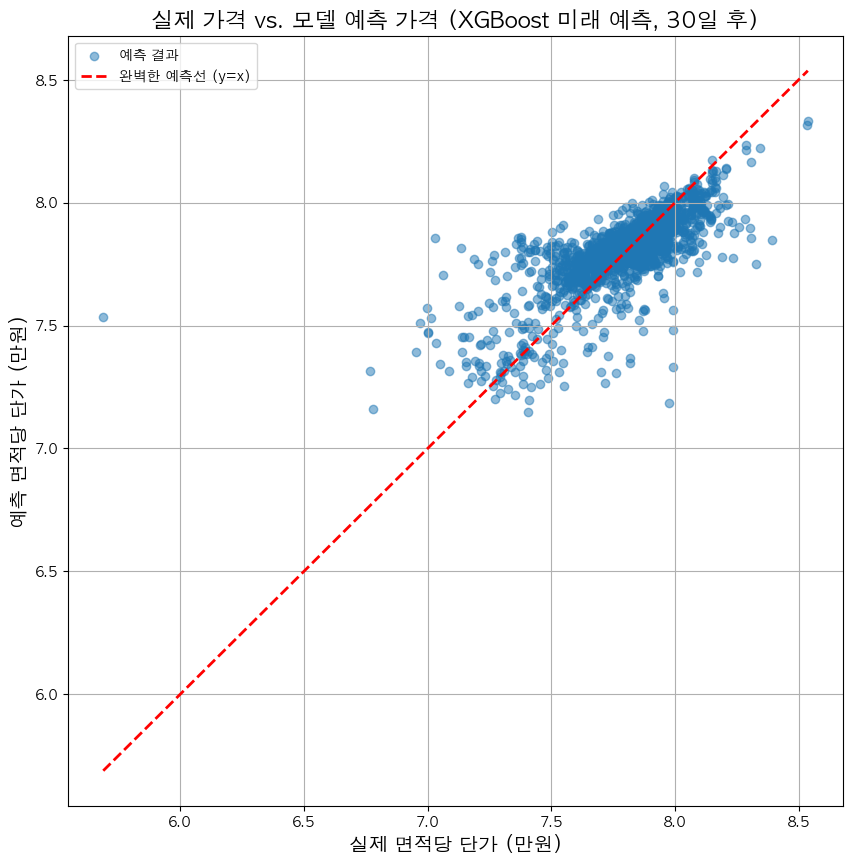

In [211]:
import matplotlib.pyplot as plt
import pandas as pd # pd.Series를 위해 import

# --- 분석 및 시각화 함수 (이전 버전에서 .values와 np.expm1 처리 확인) ---
def analyze_and_visualize_model(model, X_test_data, y_test_data, model_name, horizon_days):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_data)

    # 2. 역변환
    # y_test_data는 이미 원본 스케일이라고 가정합니다 (XGBoost fit 전에 np.log1p(y_train) 했으므로)
    # 다만, 모델 평가 지표는 로그 스케일로 계산된 것이므로 그대로 y_test_data 사용
    
    y_pred_original = np.expm1(y_pred_log)
    y_test_original = y_test_data # y_test_data는 이미 원본 스케일

    # ❗️ [수정] Series일 경우를 대비하여 .values를 사용, NumPy 배열로 통일 (y_test_original에)
    y_test_np = y_test_original.values if isinstance(y_test_original, pd.Series) else y_test_original
    
    # 3. MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(min(5, len(y_test_np))): # 데이터가 5개 미만일 경우를 대비
        print(f"실제 단가: {y_test_np.flatten()[i]:.2f} (만원)  |  예측 단가: {y_pred_original.flatten()[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    print(f"Real World MAE ({horizon_days}일 후): {real_world_mae:.2f} (만원)")


    # 5. 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    
    # x축과 y축의 범위를 동일하게 설정하여 대각선이 정확하게 보이도록
    min_val = min(y_test_np.min(), y_pred_original.min())
    max_val = max(y_test_np.max(), y_pred_original.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name}, {horizon_days}일 후)", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 모델 평가 및 시각화 실행 ---
analyze_and_visualize_model(xgboost_model, X_test, y_test, "XGBoost 미래 예측", HORIZON_DAYS)